# Aprendizaje por refuerzo: q-learning y aprendizaje de políticas π

**Objetivo del notebook.** Este material introduce los conceptos centrales del aprendizaje por refuerzo mediante ejemplos didácticos y casos de aplicación realista. Se estudian:

## 1. Conceptos básicos

En aprendizaje por refuerzo, un agente interactúa con un ambiente. En cada paso:

- El agente observa un estado \(s\).
- Elige una acción \(a\).
- Recibe una recompensa \(r\).
- Transita a un nuevo estado \(s'\).

El objetivo es aprender una política $\pi(a|s)$ que maximice la recompensa acumulada esperada.

La recompensa acumulada descontada se define como:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

donde $ \gamma \in [0,1]\$ es el factor de descuento.

Una política determinista puede escribirse como:

$
\pi(s) = a
$

y una función de valor de estado como:

$
V^\pi(s) = \mathbb{E}_{\pi}\left[G_t \mid S_t=s\right]
$

La función acción-valor se define como:

$
Q^\pi(s,a) = \mathbb{E}_{\pi}\left[G_t \mid S_t=s, A_t=a\right]
$

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional

np.random.seed(42)

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

## 2. Ambiente 1: gridworld didáctico

Se construye una cuadrícula de navegación. El agente debe ir desde una posición inicial hasta una meta. Algunas celdas son obstáculos.

### Estados

Cada estado corresponde a una celda \((fila, columna)\).

### Acciones

$
0=\text{arriba},\quad 1=\text{derecha},\quad 2=\text{abajo},\quad 3=\text{izquierda}
$

### Recompensas

- Llegar a la meta: \(+10\)
- Caer en trampa: \(-10\)
- Cada movimiento normal: \(-1\)

La penalización por movimiento incentiva rutas cortas.

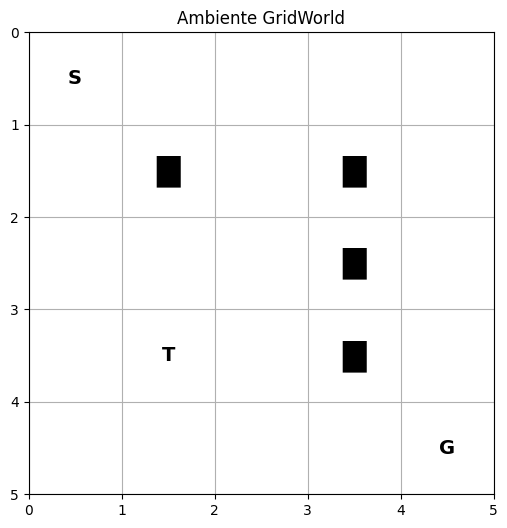

In [2]:
class GridWorld:
    def __init__(self, rows=5, cols=5, start=(0, 0), goal=(4, 4), traps=None, walls=None, max_steps=100):
        self.rows = rows
        self.cols = cols
        self.start = start
        self.goal = goal
        self.traps = set(traps or [(3, 1)])
        self.walls = set(walls or [(1, 1), (1, 3), (2, 3), (3, 3)])
        self.max_steps = max_steps
        self.actions = {
            0: (-1, 0),  # arriba
            1: (0, 1),   # derecha
            2: (1, 0),   # abajo
            3: (0, -1)   # izquierda
        }
        self.action_symbols = {0: "↑", 1: "→", 2: "↓", 3: "←"}
        self.reset()

    def state_to_idx(self, state):
        return state[0] * self.cols + state[1]

    def idx_to_state(self, idx):
        return divmod(idx, self.cols)

    @property
    def n_states(self):
        return self.rows * self.cols

    @property
    def n_actions(self):
        return 4

    def reset(self):
        self.state = self.start
        self.steps = 0
        return self.state_to_idx(self.state)

    def is_terminal(self, state):
        return state == self.goal or state in self.traps

    def valid_cell(self, state):
        r, c = state
        return 0 <= r < self.rows and 0 <= c < self.cols and state not in self.walls

    def step(self, action):
        self.steps += 1
        dr, dc = self.actions[action]
        r, c = self.state
        candidate = (r + dr, c + dc)

        if not self.valid_cell(candidate):
            candidate = self.state

        self.state = candidate

        if self.state == self.goal:
            return self.state_to_idx(self.state), 10, True, {"reason": "goal"}
        if self.state in self.traps:
            return self.state_to_idx(self.state), -10, True, {"reason": "trap"}
        if self.steps >= self.max_steps:
            return self.state_to_idx(self.state), -1, True, {"reason": "max_steps"}
        return self.state_to_idx(self.state), -1, False, {"reason": "step"}

    def render_values(self, values=None, policy=None, title="GridWorld"):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_title(title)
        ax.set_xlim(0, self.cols)
        ax.set_ylim(0, self.rows)
        ax.set_xticks(np.arange(0, self.cols + 1))
        ax.set_yticks(np.arange(0, self.rows + 1))
        ax.grid(True)
        ax.invert_yaxis()

        for r in range(self.rows):
            for c in range(self.cols):
                s = (r, c)
                x, y = c + 0.5, r + 0.5
                if s in self.walls:
                    ax.text(x, y, "█", ha="center", va="center", fontsize=22)
                elif s == self.start:
                    ax.text(x, y, "S", ha="center", va="center", fontsize=14, fontweight="bold")
                elif s == self.goal:
                    ax.text(x, y, "G", ha="center", va="center", fontsize=14, fontweight="bold")
                elif s in self.traps:
                    ax.text(x, y, "T", ha="center", va="center", fontsize=14, fontweight="bold")
                else:
                    idx = self.state_to_idx(s)
                    if policy is not None:
                        ax.text(x, y, self.action_symbols[int(policy[idx])], ha="center", va="center", fontsize=20)
                    elif values is not None:
                        ax.text(x, y, f"{values[idx]:.1f}", ha="center", va="center", fontsize=10)
        plt.show()

env = GridWorld()
env.render_values(title="Ambiente GridWorld")

## 3. Iteración de políticas: aprendizaje de una política π

La iteración de políticas es un método clásico de programación dinámica. Requiere conocer el modelo del ambiente, es decir, las transiciones y recompensas.

El algoritmo alterna dos pasos:

1. **Evaluación de política:** estima $(V^\pi(s)$ para la política actual.
2. **Mejora de política:** actualiza $\pi(s)\$ eligiendo la acción que maximiza el valor esperado.

La actualización de evaluación se basa en la ecuación de Bellman:

$
V^\pi(s) = \sum_{s'} P(s'|s,\pi(s)) \left[ R(s,\pi(s),s') + \gamma V^\pi(s') \right]
$

En este ambiente determinista, basta simular el siguiente estado para cada acción.

In [3]:
def simulate_step_for_model(env: GridWorld, state_idx: int, action: int):
    original_state = env.state
    original_steps = env.steps

    env.state = env.idx_to_state(state_idx)
    env.steps = 0
    next_state, reward, done, info = env.step(action)

    env.state = original_state
    env.steps = original_steps
    return next_state, reward, done

def policy_evaluation(env, policy, gamma=0.95, theta=1e-6, max_iter=10_000):
    V = np.zeros(env.n_states)
    terminal_states = {env.state_to_idx(env.goal)} | {env.state_to_idx(t) for t in env.traps}

    for iteration in range(max_iter):
        delta = 0
        for s in range(env.n_states):
            state_tuple = env.idx_to_state(s)
            if state_tuple in env.walls or s in terminal_states:
                continue
            a = int(policy[s])
            s_next, reward, done = simulate_step_for_model(env, s, a)
            new_v = reward if done else reward + gamma * V[s_next]
            delta = max(delta, abs(new_v - V[s]))
            V[s] = new_v
        if delta < theta:
            break
    return V, iteration + 1

def policy_improvement(env, V, gamma=0.95):
    policy = np.zeros(env.n_states, dtype=int)
    terminal_states = {env.state_to_idx(env.goal)} | {env.state_to_idx(t) for t in env.traps}

    for s in range(env.n_states):
        state_tuple = env.idx_to_state(s)
        if state_tuple in env.walls or s in terminal_states:
            policy[s] = 0
            continue

        action_values = []
        for a in range(env.n_actions):
            s_next, reward, done = simulate_step_for_model(env, s, a)
            q = reward if done else reward + gamma * V[s_next]
            action_values.append(q)

        policy[s] = int(np.argmax(action_values))
    return policy

def policy_iteration(env, gamma=0.95, max_policy_iter=100):
    policy = np.random.choice(env.n_actions, size=env.n_states)
    history = []

    for k in range(max_policy_iter):
        V, eval_iters = policy_evaluation(env, policy, gamma=gamma)
        new_policy = policy_improvement(env, V, gamma=gamma)
        changed = np.sum(policy != new_policy)
        history.append({"policy_iteration": k + 1, "changed_states": changed, "eval_iterations": eval_iters})

        if np.array_equal(policy, new_policy):
            break
        policy = new_policy

    return policy, V, pd.DataFrame(history)

policy_pi, V_pi, hist_pi = policy_iteration(env, gamma=0.95)
hist_pi

,policy_iteration,changed_states,eval_iterations
0,1,17,271
1,2,6,271
2,3,6,271
3,4,4,8
4,5,2,9
5,6,0,9


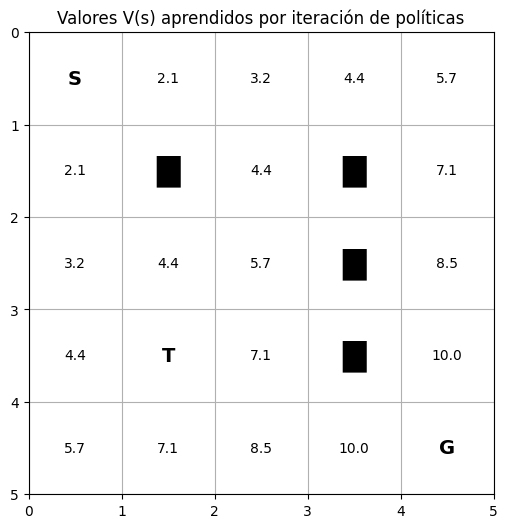

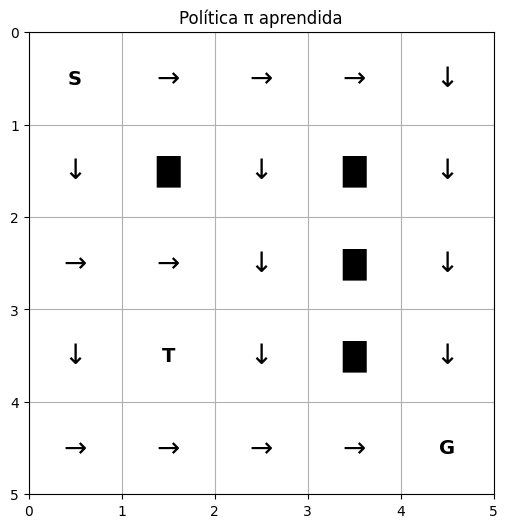

In [4]:
env.render_values(values=V_pi, title="Valores V(s) aprendidos por iteración de políticas")
env.render_values(policy=policy_pi, title="Política π aprendida")

### Interpretación

La política aprendida indica hacia dónde se debe mover el agente desde cada celda. En celdas cercanas a paredes u obstáculos, la política evita acciones que producen choques o rutas más largas.

Este método es muy eficiente cuando el modelo del ambiente es conocido, pero no siempre es posible usarlo en problemas reales. En muchos casos no se conocen las probabilidades de transición ni las recompensas futuras. En esos casos se usan métodos libres de modelo como Q-learning.

## 4. Q-learning

Q-learning aprende directamente una función \(Q(s,a)\). No necesita conocer el modelo de transición del ambiente.

La regla de actualización es:

$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\right]
$

donde:

- $\alpha$ es la tasa de aprendizaje.
- $\gamma$ es el factor de descuento.
- $\max_{a'} Q(s',a')$ representa la mejor acción futura estimada.

Q-learning es un algoritmo **off-policy**, porque aprende la política óptima aunque durante el entrenamiento explore con acciones aleatorias.

In [5]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))

def train_q_learning(env, episodes=1200, alpha=0.15, gamma=0.95, epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995):
    Q = np.zeros((env.n_states, env.n_actions))
    rewards = []
    steps_list = []
    epsilon = epsilon_start

    for ep in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, env.n_actions)
            next_state, reward, done, info = env.step(action)

            td_target = reward if done else reward + gamma * np.max(Q[next_state])
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
        steps_list.append(steps)

    policy = np.argmax(Q, axis=1)
    return Q, policy, rewards, steps_list

Q, policy_q, rewards_q, steps_q = train_q_learning(env)

print("Recompensa promedio últimos 100 episodios:", np.mean(rewards_q[-100:]))
print("Pasos promedio últimos 100 episodios:", np.mean(steps_q[-100:]))

Recompensa promedio últimos 100 episodios: 1.86
Pasos promedio últimos 100 episodios: 8.14


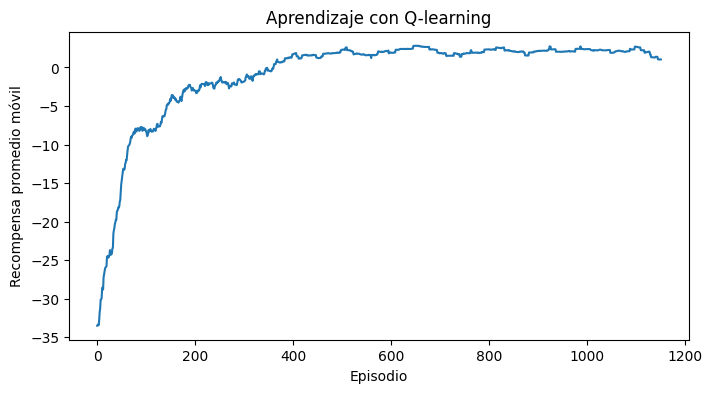

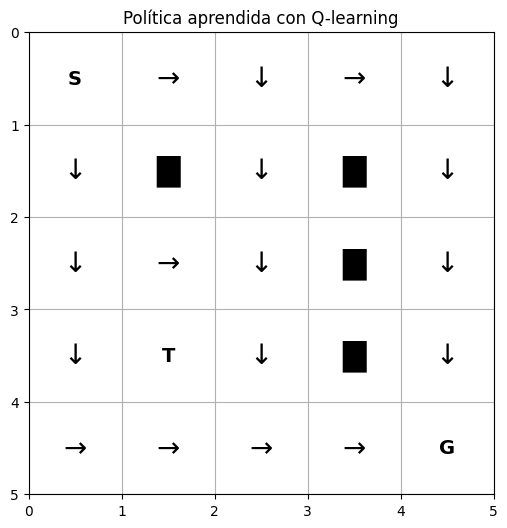

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(moving_average(rewards_q, 50))
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio móvil")
plt.title("Aprendizaje con Q-learning")
plt.show()

env.render_values(policy=policy_q, title="Política aprendida con Q-learning")